# NeuralMag vortex Ms fit with LLG

This notebook is a compact, shareable example of a differentiable NeuralMag workflow. It builds a cylindrical vortex, relaxes it at two saturation magnetizations, projects the resulting magnetization through the MBIR phase model, and fits `Msat` back from the target phase image.

The workflow is intentionally simple:

1. define the cylinder, material, and two `Msat` cases;
2. generate relaxed reference states with fixed-time LLG;
3. use the 300 kA/m state as the initial guess and the 800 kA/m phase as the target;
4. run a differentiable NeuralMag LLG solve inside a scalar Adam fit for `Msat`.


## Setup

Run this notebook from a fresh environment created in the standalone repo root:

```bash
python -m venv .venv
source .venv/bin/activate
python -m pip install --upgrade pip
pip install -r requirements.txt
python -m ipykernel install --user --name vortex-llg-demo --display-name "Python (vortex-llg-demo)"
jupyter lab
```

Then select the `Python (vortex-llg-demo)` kernel and run the notebook from the top. The first code cell sets JAX float64 flags before importing JAX, so it should always be executed first in a fresh kernel.


## Problem Setup

These parameters define the synthetic vortex problem, the fixed-time LLG reference solves, and the outer Adam fit. The values are deliberately modest so the notebook remains practical on a laptop or workstation.


In [ ]:
from __future__ import annotations

import os
import time

# JAX reads these flags at import time, so set them before importing jax.
os.environ["JAX_ENABLE_X64"] = "1"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.4"

from jax import config as jax_config

jax_config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import unxt as u

try:
    from libertem_holo.base.mbir import MU_0, forward_phase_from_density_and_magnetization
except ImportError as exc:
    raise ImportError(
        "This notebook requires libertem-holo. Install the standalone repo requirements with `pip install -r requirements.txt`, then restart the kernel."
    ) from exc

try:
    import neuralmag as nm
except ImportError as exc:
    raise ImportError(
        "This notebook requires `neuralmag[jax]`. Install the standalone repo requirements with `pip install -r requirements.txt`, then restart the kernel."
    ) from exc

nm.config.dtype = "float64"
backend = getattr(getattr(nm, "config", None), "backend", None)
backend_name = getattr(backend, "name", backend)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["image.origin"] = "lower"
np.set_printoptions(precision=5, suppress=True)

print(f"NeuralMag backend: {backend_name}")


2026-05-01 15:27:20 NeuralMag:INFO [NeuralMag] Version 0.9.4
2026-05-01 15:27:21 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2026-05-01 15:27:21 NeuralMag:INFO [NeuralMag] Set default dtype to 'float64'.


NeuralMag backend: jax


In [2]:
shape_xyz = (64, 64, 20)
cellsize_nm_xyz = np.array([5.0, 5.0, 1.0], dtype=np.float64)
diameter_nm = 320.0
thickness_nm = 20.0

material = {
    "A_J_per_m": 1.0e-11,
    "Di_J_per_m2": 0.0,
    "Ku_J_per_m3": 0.0,
    "alpha": 1.0,
}

msat_cases = {
    "800 kA/m": 800e3,
    "300 kA/m": 300e3,
}

target_case = "800 kA/m"
input_case = "300 kA/m"

llg_solve_time_s = 1.1e-10
demag_p = 3

outer_steps = 100
outer_learning_rate = 0.15
msat_bounds = (2e5, 1.0e6)

print(f"Grid: {shape_xyz}, cell size xyz: {cellsize_nm_xyz} nm")
print(f"Cylinder: {diameter_nm:g} nm diameter, {thickness_nm:g} nm thick")
print("Material:", material)
print("Msat cases:", msat_cases)
print(f"LLG solve horizon: {llg_solve_time_s:.3e} s")


Grid: (64, 64, 20), cell size xyz: [5. 5. 1.] nm
Cylinder: 320 nm diameter, 20 nm thick
Material: {'A_J_per_m': 1e-11, 'Di_J_per_m2': 0.0, 'Ku_J_per_m3': 0.0, 'alpha': 1.0}
Msat cases: {'800 kA/m': 800000.0, '300 kA/m': 300000.0}
LLG solve horizon: 1.100e-10 s


## Geometry, State, and Phase Helpers

This section keeps the mechanics in one place: build the cylinder support, create an initial vortex seed, construct a NeuralMag state, and convert relaxed magnetization into the MBIR phase image used by the fit.


In [ ]:
def cell_centers_nm(shape_xyz, spacing_nm_xyz):
    axes = [
        (np.arange(n, dtype=np.float64) + 0.5) * spacing - (n * spacing / 2.0)
        for n, spacing in zip(shape_xyz, spacing_nm_xyz)
    ]
    return np.meshgrid(*axes, indexing="ij")


def cylinder_support_xyz(shape_xyz, spacing_nm_xyz, diameter_nm, thickness_nm):
    xx, yy, zz = cell_centers_nm(shape_xyz, spacing_nm_xyz)
    r = diameter_nm / 2.0
    support = (xx**2 + yy**2 <= r**2) & (np.abs(zz) <= thickness_nm / 2.0)
    return support.astype(np.float32)


def normalize_m(m_xyz, support_xyz, threshold=0.5):
    norm = np.linalg.norm(m_xyz, axis=-1, keepdims=True)
    unit = m_xyz / np.where(norm > 0.0, norm, 1.0)
    return np.where(support_xyz[..., None] > threshold, unit, 0.0).astype(np.float32)


def vortex_seed_xyz(support_xyz, spacing_nm_xyz, *, circulation=1, polarization=-1, core_radius_nm=18.0):
    xx, yy, _ = cell_centers_nm(support_xyz.shape, spacing_nm_xyz)
    phi = np.arctan2(yy, xx)
    radius = np.hypot(xx, yy)
    mz = polarization * np.exp(-((radius / core_radius_nm) ** 2))
    in_plane = np.sqrt(np.maximum(1.0 - mz**2, 0.0))

    m = np.zeros(support_xyz.shape + (3,), dtype=np.float32)
    m[..., 0] = -circulation * np.sin(phi) * in_plane
    m[..., 1] = circulation * np.cos(phi) * in_plane
    m[..., 2] = mz
    return normalize_m(m, support_xyz)


def build_vortex_state(rho_cell_xyz, m_cell_xyz, msat_a_per_m):
    # Build one fully-registered NeuralMag state from cell-centered support, seed, and material fields.
    mesh = nm.Mesh(tuple(rho_cell_xyz.shape), tuple((cellsize_nm_xyz * 1e-9).tolist()))
    state = nm.State(mesh)

    rho_min = float(getattr(state, "eps", 1e-12))
    state.rho = nm.CellFunction(state, tensor=state.tensor(np.clip(rho_cell_xyz, rho_min, 1.0), dtype=state.dtype))
    state.material.Ms = nm.CellFunction(state).fill(float(msat_a_per_m))
    state.material.A = nm.CellFunction(state).fill(material["A_J_per_m"])
    state.material.Di = nm.CellFunction(state).fill(material["Di_J_per_m2"])
    axis_values = np.broadcast_to(np.array([0.0, 0.0, 1.0], dtype=np.float64), tuple(rho_cell_xyz.shape) + (3,)).copy()
    axis_field = nm.VectorCellFunction(state, tensor=state.tensor(axis_values, dtype=state.dtype))
    state.material.Di_axis = axis_field
    state.material.Ku = nm.CellFunction(state).fill(material["Ku_J_per_m3"])
    state.material.Ku_axis = axis_field
    state.material.alpha = state.tensor(float(material["alpha"]))

    rho_cell = nm.CellFunction(state, tensor=state.tensor(rho_cell_xyz, dtype=state.dtype))
    m_cell = nm.VectorCellFunction(state, tensor=state.tensor(m_cell_xyz, dtype=state.dtype))
    rho_node = np.asarray(rho_cell.to_node().tensor)
    m_node = np.asarray(m_cell.to_node().tensor)
    norm = np.linalg.norm(m_node, axis=-1, keepdims=True)
    m_node = np.where(rho_node[..., None] > 0.5, m_node / np.where(norm > 0.0, norm, 1.0), 0.0)
    state.m = nm.VectorFunction(state, tensor=state.tensor(m_node, dtype=state.dtype))
    state.t = state.tensor(0.0)

    nm.ExchangeField().register(state, "exchange")
    nm.DemagField(p=demag_p).register(state, "demag")
    nm.InterfaceDMIField().register(state, "idmi")
    nm.UniaxialAnisotropyField().register(state, "uaniso")
    nm.TotalField("exchange", "demag", "idmi", "uaniso").register(state)
    return state


def relax_fixed_time_llg(rho_cell_xyz, m_cell_xyz, msat_a_per_m):
    # Use the same solve horizon for every reference state so the comparison stays controlled.
    state = build_vortex_state(rho_cell_xyz, m_cell_xyz, msat_a_per_m)
    solver = nm.LLGSolver(state)
    state.m.tensor = solver.solve(state.tensor([0.0, llg_solve_time_s])).ys[-1]
    return state


def phase_from_m_xyz(rho_xyz, m_xyz, msat_a_per_m, *, dtype=np.float32):
    # Convert cell magnetization into the MBIR phase image that the outer fit sees.
    rho_xyz = np.asarray(rho_xyz, dtype=dtype)
    m_xyz = np.asarray(m_xyz, dtype=dtype)
    reference_induction = u.Quantity(float(np.asarray(MU_0.value, dtype=dtype)) * float(msat_a_per_m), "T")
    return np.asarray(
        forward_phase_from_density_and_magnetization(
            rho=rho_xyz,
            magnetization_3d=m_xyz,
            pixel_size=u.Quantity(float(cellsize_nm_xyz[0]), "nm"),
            reference_induction=reference_induction,
            projection_step_size=u.Quantity(float(cellsize_nm_xyz[2]), "nm"),
            axis="z",
            geometry="disc",
        ),
        dtype=dtype,
    )


## Reference States

Here the notebook runs two fixed-time LLG relaxations, one at low `Msat` and one at high `Msat`. Those two reference states define the input magnetization and the target phase image for the inverse problem. Each run also reports the final `max |dm/dt|` so you can judge how close the state is to equilibrium.


In [4]:
rho_cell = cylinder_support_xyz(shape_xyz, cellsize_nm_xyz, diameter_nm, thickness_nm)
m0_cell = vortex_seed_xyz(rho_cell, cellsize_nm_xyz, circulation=1, polarization=-1)

results = {}
for label, msat in msat_cases.items():
    print(f"Relaxing {label} with fixed-time LLG ...")
    started = time.perf_counter()
    state = relax_fixed_time_llg(rho_cell, m0_cell, msat)

    m_relaxed = normalize_m(np.asarray(state.m.to_cell().tensor), rho_cell)
    rho_relaxed = np.asarray(state.rho.tensor, dtype=np.float32)
    phase_yx = phase_from_m_xyz(rho_relaxed, m_relaxed, msat)

    results[label] = {
        "Ms_A_per_m": float(msat),
        "rho": rho_relaxed,
        "m": m_relaxed,
        "m0": m0_cell,
        "phase_yx": phase_yx,
        "elapsed_s": time.perf_counter() - started,
    }


2026-05-01 15:27:21 NeuralMag:INFO [Mesh] 3D, 64 x 64 x 20 (size = 5e-09 x 5e-09 x 1e-09)
2026-05-01 15:27:21 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-05-01 15:27:21 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)


Support voxels: 64560
Initial |m| on support: 1.00000
Relaxing 800 kA/m with fixed-time LLG ...


2026-05-01 15:27:22 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-05-01 15:27:22 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-05-01 15:27:22 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-05-01 15:27:36 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_idmi', energy: 'E_idmi', energy density: 'e_idmi')
2026-05-01 15:27:36 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uaniso', energy: 'E_uaniso', energy density: 'e_uaniso')
2026-05-01 15:27:36 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-05-01 15:27:36 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function
2026-05-01 15:28:25 NeuralMag:INFO [Mesh] 3D, 64 x 64 x 20 (size = 5e-09 x 5e-09 x 1e-09)
2026-05-01 15:28:25 NeuralMag:INFO [NeuralMag] Set default device to 'cud

  64.16s | mean m = [-0.       0.      -0.00225] | max |dm/dt| = 2.117e+08 rad/s
Relaxing 300 kA/m with fixed-time LLG ...


2026-05-01 15:28:26 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-05-01 15:28:26 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-05-01 15:28:26 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-05-01 15:28:38 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_idmi', energy: 'E_idmi', energy density: 'e_idmi')
2026-05-01 15:28:38 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uaniso', energy: 'E_uaniso', energy density: 'e_uaniso')
2026-05-01 15:28:38 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-05-01 15:28:38 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function


  74.48s | mean m = [-0.       0.      -0.01852] | max |dm/dt| = 5.112e+08 rad/s


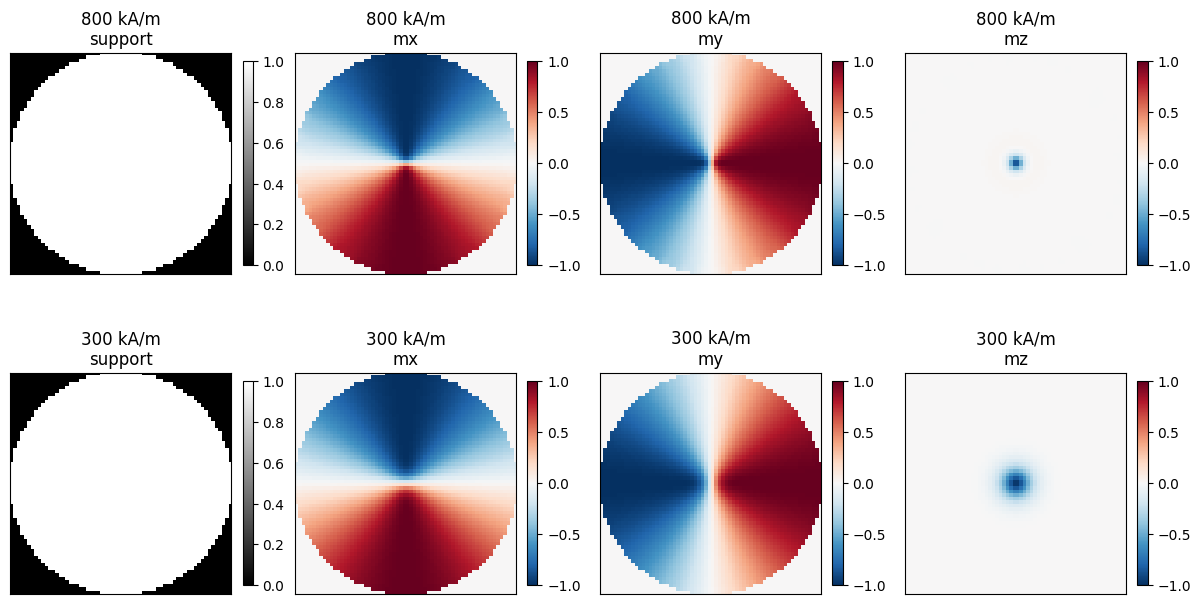

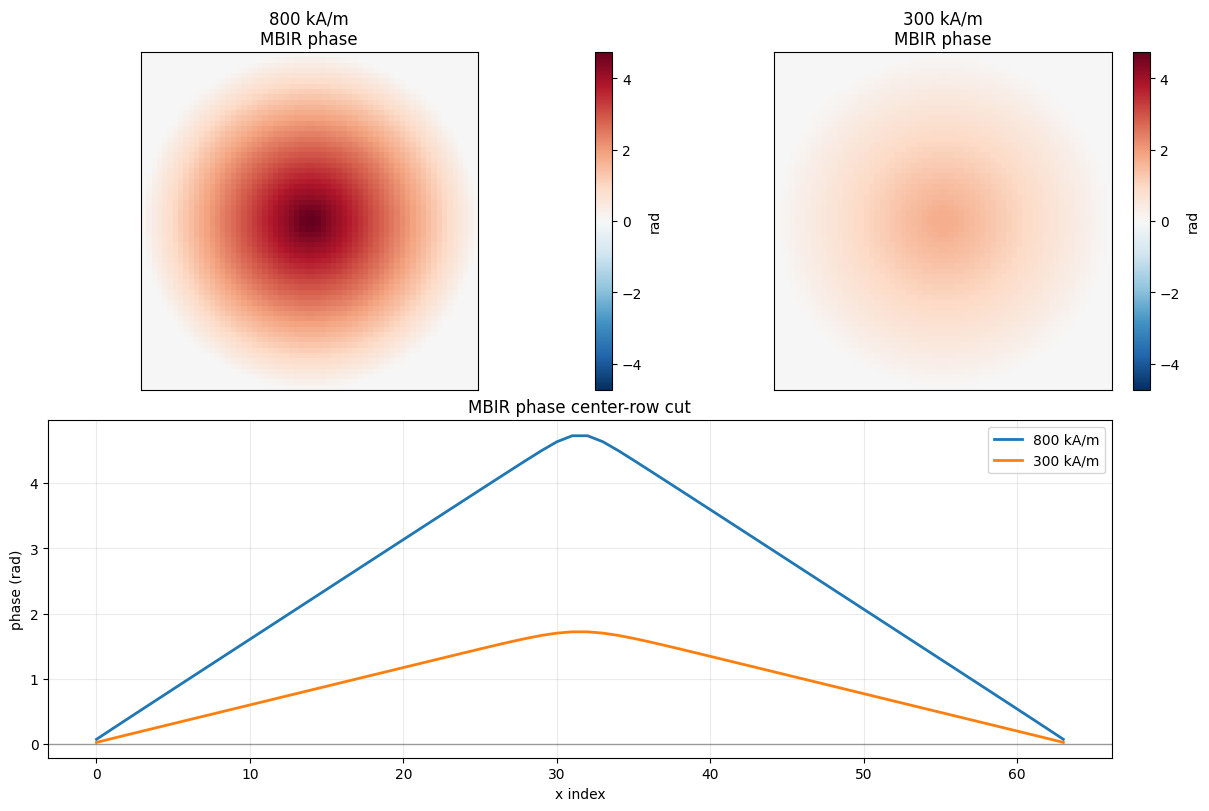

In [5]:
fig, axs = plt.subplots(len(results), 4, figsize=(12, 3.2 * len(results)), constrained_layout=True)
axs = np.atleast_2d(axs)

for row, (label, result) in enumerate(results.items()):
    rho = result["rho"]
    m = result["m"]
    mid = rho.shape[2] // 2
    panels = [
        (rho[:, :, mid].T, "support", "gray", 0.0, 1.0),
        (m[:, :, mid, 0].T, "mx", "RdBu_r", -1.0, 1.0),
        (m[:, :, mid, 1].T, "my", "RdBu_r", -1.0, 1.0),
        (m[:, :, mid, 2].T, "mz", "RdBu_r", -1.0, 1.0),
    ]
    for col, (image, title, cmap, vmin, vmax) in enumerate(panels):
        im = axs[row, col].imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
        axs[row, col].set_title(f"{label}\n{title}")
        axs[row, col].set_xticks([])
        axs[row, col].set_yticks([])
        plt.colorbar(im, ax=axs[row, col], fraction=0.046)

plt.show()

phase_lim = max(max(abs(float(r["phase_yx"].min())), abs(float(r["phase_yx"].max()))) for r in results.values())
phase_lim = max(phase_lim, 1e-12)
fig = plt.figure(figsize=(12, 8), constrained_layout=True)
gs = fig.add_gridspec(2, len(results))

for col, (label, result) in enumerate(results.items()):
    ax = fig.add_subplot(gs[0, col])
    im = ax.imshow(result["phase_yx"], cmap="RdBu_r", vmin=-phase_lim, vmax=phase_lim)
    ax.set_title(f"{label}\nMBIR phase")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, label="rad")

ax = fig.add_subplot(gs[1, :])
x_index = np.arange(shape_xyz[0])
for label, result in results.items():
    phase = result["phase_yx"]
    ax.plot(x_index, phase[phase.shape[0] // 2], linewidth=2.0, label=label)
ax.axhline(0.0, color="k", linewidth=1.0, alpha=0.35)
ax.set_title("MBIR phase center-row cut")
ax.set_xlabel("x index")
ax.set_ylabel("phase (rad)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


## Differentiable `Msat` fit

The outer optimization adjusts a single scalar parameter, `Msat`. Each candidate value is mapped into physical bounds, used in a differentiable LLG solve over a shared time horizon, projected into phase space, and compared to the target phase with an RMS loss.


In [ ]:
target = results[target_case]
source = results[input_case]
solver_dtype = jnp.float64

rho_xyz = jnp.asarray(target["rho"], dtype=solver_dtype)
support_cell = rho_xyz > 0.5
mu0 = jnp.asarray(MU_0.value, dtype=solver_dtype)
target_msat = float(target["Ms_A_per_m"])
input_msat = float(source["Ms_A_per_m"])
target_m_cell = jnp.asarray(target["m"], dtype=solver_dtype)
input_m_cell = jnp.asarray(source["m"], dtype=solver_dtype)
target_phase = jnp.asarray(target["phase_yx"], dtype=solver_dtype)
input_phase = jnp.asarray(phase_from_m_xyz(source["rho"], source["m"], input_msat), dtype=solver_dtype)

fit_state = build_vortex_state(np.asarray(rho_xyz), np.asarray(input_m_cell), input_msat)
node_to_cell = fit_state.resolve(lambda f: nm.VectorFunction(fit_state, tensor=f).to_cell().tensor, ["f"])
rho_node = jnp.asarray(fit_state.rho.to_node().tensor, dtype=solver_dtype)
support_node = rho_node > 0.5

msat_min, msat_max = msat_bounds
input_fraction = np.clip((input_msat - msat_min) / (msat_max - msat_min), 1e-12, 1.0 - 1e-12)
theta0 = jnp.asarray(np.log(input_fraction / (1.0 - input_fraction)), dtype=solver_dtype)
fit_times = jnp.asarray([0.0, llg_solve_time_s], dtype=solver_dtype)


def bounded_msat(theta):
    # Keep the optimizer variable unconstrained while the physical Msat stays inside the requested bounds.
    return msat_min + (msat_max - msat_min) * jax.nn.sigmoid(theta)


def normalize_on_support(field, support):
    mask = support.astype(field.dtype)[..., None]
    eps = jnp.finfo(field.dtype).eps
    norm = jnp.sqrt(jnp.sum(field * field, axis=-1, keepdims=True) + eps**2)
    return mask * field / norm


def cell_from_node(m_node):
    return normalize_on_support(node_to_cell(normalize_on_support(m_node, support_node)), support_cell)


def phase_from_cell_jax(m_cell, msat):
    reference_induction = u.Quantity(mu0 * msat, "T")
    return forward_phase_from_density_and_magnetization(
        rho=rho_xyz,
        magnetization_3d=normalize_on_support(m_cell, support_cell),
        pixel_size=u.Quantity(float(cellsize_nm_xyz[0]), "nm"),
        reference_induction=reference_induction,
        projection_step_size=u.Quantity(float(cellsize_nm_xyz[2]), "nm"),
        axis="z",
        geometry="disc",
    )


fit_llg_solver = nm.LLGSolver(
    fit_state,
    parameters=["material__Ms"],
)


def relax(msat):
    # This is the differentiable inner solve that the outer optimizer sees.
    return fit_llg_solver.solve(
        fit_times,
        jnp.full(rho_xyz.shape, msat, dtype=solver_dtype),
    ).ys[-1]


@jax.jit
def loss(theta):
    msat = bounded_msat(theta)
    m_final = cell_from_node(relax(msat))
    residual = phase_from_cell_jax(m_final, msat) - target_phase
    return 0.5 * jnp.mean(residual * residual)


@jax.jit
def loss_and_grad(theta):
    return jax.value_and_grad(loss)(theta)


print(f"Target: {target_case} ({target_msat / 1e3:.0f} kA/m)")
print(f"Input:  {input_case} ({input_msat / 1e3:.0f} kA/m)")
print(f"Initial theta maps to {float(bounded_msat(theta0)) / 1e3:.1f} kA/m")
print(f"Inner LLG solve horizon: {llg_solve_time_s:.3e}s")


2026-05-01 15:29:41 NeuralMag:INFO [Mesh] 3D, 64 x 64 x 20 (size = 5e-09 x 5e-09 x 1e-09)
2026-05-01 15:29:41 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-05-01 15:29:41 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)
2026-05-01 15:29:42 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-05-01 15:29:42 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-05-01 15:29:42 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-05-01 15:29:54 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_idmi', energy: 'E_idmi', energy density: 'e_idmi')
2026-05-01 15:29:54 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uaniso', energy: 'E_uaniso', energy density: 'e_uaniso')
2026-05-01 15:29:54 NeuralMag:INFO [TotalField] Register state methods (field: 'h', 

Target: 800 kA/m (800 kA/m)
Input:  300 kA/m (300 kA/m)
Initial theta maps to 300.0 kA/m
Inner LLG solve horizon: 1.100e-10s


In [ ]:
def run_adam(theta, *, steps=outer_steps, learning_rate=outer_learning_rate, log_every=25):
    opt = optax.adam(learning_rate)
    opt_state = opt.init(theta)
    history = []

    # Warm up the compiled loss once so the reported optimization time is easier to interpret.
    started = time.perf_counter()
    warmup_loss, _ = loss_and_grad(theta)
    jax.block_until_ready(warmup_loss)
    compile_elapsed_s = time.perf_counter() - started

    started = time.perf_counter()
    for step in range(int(steps)):
        loss_value, grad = loss_and_grad(theta)
        updates, opt_state = opt.update(grad, opt_state, theta)
        theta = optax.apply_updates(theta, updates)

        msat = float(jax.device_get(bounded_msat(theta)))
        phase_rms = float(jax.device_get(jnp.sqrt(2.0 * loss_value)))
        history.append({
            "step": step, "msat": msat, "phase_rms": phase_rms,
            "elapsed_s": time.perf_counter() - started,
        })

        if step == 0 or (step + 1) % log_every == 0 or step + 1 == steps:
            print(f"{step + 1:4d}/{steps}: Msat={msat / 1e3:8.2f} kA/m | phase RMS={phase_rms:.6g}")

    # Evaluate the converged parameters once more to collect final phase, magnetization, and convergence outputs.
    msat_final = bounded_msat(theta)
    m_final_node = relax(msat_final)
    m_final = cell_from_node(m_final_node)
    phase_pred = phase_from_cell_jax(m_final, msat_final)
    residual = phase_pred - target_phase
    max_dm_dt = float(jax.device_get(llg_max_dm_dt(fit_state, m_final_node, msat=msat_final)))

    return {
        "theta": theta,
        "msat": float(jax.device_get(msat_final)),
        "phase_rms": float(jax.device_get(jnp.sqrt(jnp.mean(residual * residual)))),
        "max_dm_dt": max_dm_dt,
        "phase_pred": np.asarray(jax.device_get(phase_pred)),
        "m_cell_final": np.asarray(jax.device_get(m_final)),
        "history": history,
        "compile_elapsed_s": compile_elapsed_s,
        "optimizer_elapsed_s": history[-1]["elapsed_s"] if history else 0.0,
    }


fit_result = run_adam(theta0)
print(
    f"Final Msat={fit_result['msat'] / 1e3:.2f} kA/m | "
    f"phase RMS={fit_result['phase_rms']:.6g} rad | "
    f"max |dm/dt|={fit_result['max_dm_dt']:.3e} rad/s | "
    f"compile={fit_result['compile_elapsed_s']:.2f}s, optimize={fit_result['optimizer_elapsed_s']:.2f}s"
)


   1/100: Msat=  313.88 kA/m | phase RMS=1.10901


## Diagnostics

The final plots show whether the fitted `Msat` reproduces both the target phase and the relaxed magnetization pattern. The first row focuses on optimization history, and the second figure compares input, target, and fitted states side by side.


In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


def as_np(value):
    return np.asarray(jax.device_get(value), dtype=np.float64)


def add_colorbar(ax, im, label):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.05)
    cb = plt.colorbar(im, cax=cax)
    cb.set_label(label)


def show_m_slice(ax, m_cell, title, *, quiver_step=5):
    mid = m_cell.shape[2] // 2
    im = ax.imshow(m_cell[:, :, mid, 2].T, cmap="RdBu_r", vmin=-1.0, vmax=1.0)
    x = np.arange(0, m_cell.shape[0], quiver_step)
    y = np.arange(0, m_cell.shape[1], quiver_step)
    xx, yy = np.meshgrid(x, y, indexing="xy")
    ax.quiver(
        xx,
        yy,
        m_cell[::quiver_step, ::quiver_step, mid, 0].T,
        m_cell[::quiver_step, ::quiver_step, mid, 1].T,
        color="k",
        pivot="mid",
        scale=22,
        width=0.004,
        alpha=0.75,
    )
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return im


def show_phase(ax, phase, title, limit):
    im = ax.imshow(phase, cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return im


history = fit_result["history"]
fig, axs = plt.subplots(1, 3, figsize=(13, 3.4), constrained_layout=True)
steps = np.array([row["step"] for row in history])
rms = np.array([row["phase_rms"] for row in history])
msat = np.array([row["msat"] for row in history])
elapsed = np.array([row["elapsed_s"] for row in history])

axs[0].semilogy(steps, np.maximum(rms, 1e-30), marker="o")
axs[0].set_title("Phase convergence")
axs[0].set_xlabel("Adam step")
axs[0].set_ylabel("Phase RMS (rad)")
axs[0].grid(True, alpha=0.25)

axs[1].plot(steps, msat / 1e3, marker="o", label="fit")
axs[1].axhline(target_msat / 1e3, color="k", ls="--", lw=1.0, label="target")
axs[1].set_title("Msat trajectory")
axs[1].set_xlabel("Adam step")
axs[1].set_ylabel("kA/m")
axs[1].grid(True, alpha=0.25)
axs[1].legend()

axs[2].semilogy(np.maximum(elapsed, 1e-9), np.maximum(rms, 1e-30), marker="o")
axs[2].set_title("RMS versus runtime")
axs[2].set_xlabel("Optimizer wall time (s)")
axs[2].set_ylabel("Phase RMS (rad)")
axs[2].grid(True, alpha=0.25)
plt.show()

input_m_np = as_np(input_m_cell)
target_m_np = as_np(target_m_cell)
fit_m_np = as_np(fit_result["m_cell_final"])
input_phase_np = as_np(input_phase)
target_phase_np = as_np(target_phase)
fit_phase_np = as_np(fit_result["phase_pred"])
phase_resid_np = fit_phase_np - target_phase_np
m_error_np = np.linalg.norm(fit_m_np - target_m_np, axis=-1)

phase_lim = max(abs(float(arr.min())) for arr in (input_phase_np, target_phase_np, fit_phase_np))
phase_lim = max(phase_lim, max(abs(float(arr.max())) for arr in (input_phase_np, target_phase_np, fit_phase_np)), 1e-12)
resid_lim = max(abs(float(phase_resid_np.min())), abs(float(phase_resid_np.max())), 1e-12)
merr_lim = max(float(np.nanmax(m_error_np)), 1e-12)

fig = plt.figure(figsize=(18.5, 11.0), constrained_layout=True)
gs = fig.add_gridspec(3, 4, height_ratios=[1.0, 1.0, 0.85])
fig.suptitle("Differentiable NeuralMag LLG fit", fontsize=14)

panels = [
    (0, 0, show_m_slice, input_m_np, "Input magnetization", "m_z", None),
    (0, 1, show_phase, input_phase_np, "Input phase", "phase (rad)", phase_lim),
    (0, 2, show_m_slice, target_m_np, "Ground truth magnetization", "m_z", None),
    (0, 3, show_phase, target_phase_np, "Ground truth phase", "phase (rad)", phase_lim),
    (1, 0, show_m_slice, fit_m_np, "Fit magnetization", "m_z", None),
    (1, 1, show_phase, fit_phase_np, "Fit phase", "phase (rad)", phase_lim),
]

for row, col, plot_fn, values, title, cbar_label, limit in panels:
    ax = fig.add_subplot(gs[row, col])
    im = plot_fn(ax, values, title) if limit is None else plot_fn(ax, values, title, limit)
    add_colorbar(ax, im, cbar_label)

ax = fig.add_subplot(gs[1, 2])
im = ax.imshow(m_error_np[:, :, m_error_np.shape[2] // 2].T, cmap="magma", vmin=0.0, vmax=merr_lim)
ax.set_title("|fit m - truth m|")
ax.set_xticks([])
ax.set_yticks([])
add_colorbar(ax, im, "|dm|")

ax = fig.add_subplot(gs[1, 3])
im = show_phase(ax, phase_resid_np, "Phase residual", resid_lim)
add_colorbar(ax, im, "rad")

ax = fig.add_subplot(gs[2, :])
x_index = np.arange(target_phase_np.shape[1])
row = target_phase_np.shape[0] // 2
ax.plot(x_index, input_phase_np[row], lw=1.5, label="input")
ax.plot(x_index, target_phase_np[row], lw=2.0, label="ground truth")
ax.plot(x_index, fit_phase_np[row], lw=1.8, label="fit")
ax.axhline(0.0, color="k", lw=1.0, alpha=0.25)
ax.set_title("Center-row phase profiles")
ax.set_xlabel("x index")
ax.set_ylabel("phase (rad)")
ax.grid(True, alpha=0.25)
ax.legend(ncol=3, loc="best")
plt.show()
